# Plotting animations of land cover <img align="right" src="../Supplementary_data/dea_logo.jpg">

* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Compatibility:** Notebook currently compatible with the `DEA Sandbox` environment
* **Products used:** 
[ga_ls_landcover_class_cyear_3](https://explorer.dea.ga.gov.au/products/ga_ls_landcover_class_cyear_3)


## Background

Land cover is the physical surface of the Earth, including trees, shrubs, grasses, soils, exposed rocks, water bodies, plantations, crops and built structures.
Digital Earth Australia Land Cover (DEA Land Cover) is a continental dataset that maps annual land cover classifications for Australia from 1988 to the present. 
Detailed information about DEA Land Cover can be found in the [DEA Land Cover notebook](../DEA_products/DEA_Land_Cover.ipynb) and on the [DEA Land Cover product details](https://knowledge.dea.ga.gov.au/data/product/dea-land-cover-landsat) page.

## Description

This notebook introduces the `lc_animation()` function and demonstrates how it can be used to visualise and communicate change over time.
Topics covered include: 

1. Loading a time series of DEA Land Cover data as an `xarray` dataset.
2. Plotting land cover as an animation.
3. Plotting a stacked line plot next to a land cover animation.
4. Modifying the way land cover is plotted as an animation.

***

## Getting started
To run this analysis, run all the cells in the notebook starting with the 'Load packages' cell.

### Load packages

In [1]:
%matplotlib inline

import os
import sys

import datacube
import numpy as np
import xarray as xr

sys.path.insert(1, os.path.abspath("../Tools"))
from dea_tools.landcover import lc_animation
from dea_tools.plotting import display_map


### Connect to the datacube
Connect to the datacube so we can access DEA data. 

In [2]:
dc = datacube.Datacube(app="Land_cover_animated_plots")

### Create query and load a time series of land cover data

In order to generate animations of DEA Land Cover, we first need to load a time series of data for an area. 
As an example, let's load both the base 6-class classification (Level 3) layer and the full classification (Level 4) layer for Lake Wallawalla. 
This waterbody is located in the Murray River Valley in north-western Victoria, and goes through cycles of drying and filling.

In [3]:
# Lake Wallawalla
point_x, point_y = (-34.1795, 141.1937)

lat = (point_x - 0.03, point_x + 0.03)
lon = (point_y - 0.03, point_y + 0.03)

# Display area on map
display_map(x=lon, y=lat)

In [4]:
# Build query and load data
query = {
    "y": lat,
    "x": lon,
    "time": ("1988", "2021"),
}

# Load DEA Land Cover data from the datacube
land_cover_data = dc.load(
    product="ga_ls_landcover_class_cyear_3",
    output_crs="EPSG:3577",
    measurements=["level3", "level4"],
    resolution=(-30, 30),
    **query
)

In [5]:
# See what we have loaded
land_cover_data

<xarray.Dataset> Size: 3MB
Dimensions:      (time: 34, y: 237, x: 200)
Coordinates:
  * time         (time) datetime64[ns] 272B 1988-07-01T23:59:59.999999 ... 20...
  * y            (y) float64 2kB -3.758e+06 -3.758e+06 ... -3.765e+06 -3.765e+06
  * x            (x) float64 2kB 8.398e+05 8.398e+05 ... 8.457e+05 8.458e+05
    spatial_ref  int32 4B 3577
Data variables:
    level3       (time, y, x) uint8 2MB 111 111 111 111 111 ... 112 216 216 112
    level4       (time, y, x) uint8 2MB 16 16 16 16 17 34 ... 35 35 35 96 96 35
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

## Plot land cover animations 

### Plot default animation of Level 3 data

`lc_animation()` has a number of options for controlling the inclusion of colour bars and tick marks and the ability to add an animated stacked line plot beside the animated map. 
To begin, let's plot the Level 3 layer with all default options. 
This will plot a single animated map with tick marks and no colour bar. A copy of the animation will be saved to file as `default_animation.gif`. 
This name can be changed by providing an alternative as the variable `file_name` as will be done in following examples.

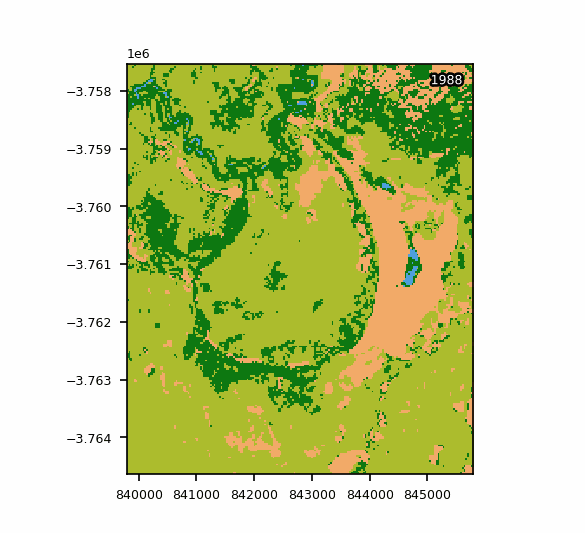

In [6]:
# Select Level 3 data
level_3 = land_cover_data["level3"]

# Generate plot
lc_animation(level_3, 
            width_pixels=3,
            font_size=6)

### Plot animation with a stacked line plot

Adding the optional setting `stacked_plot=True` will generate a stacked line plot that is synchronised with the animated map. The stacked line plot shows what percentage of the map is taken up by each class in each year.
For this example we will use the full classification, Level 4 layer.

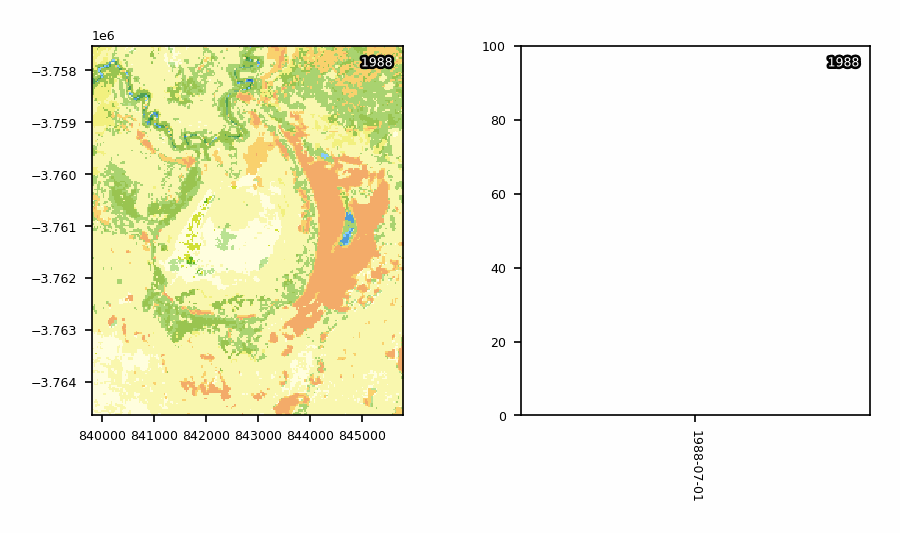

In [7]:
# Select Level 4
level_4 = land_cover_data["level4"]

# Set file name
file_name = "level_4_with_stacked_plot"

# Generate plot
lc_animation(level_4, 
             file_name=file_name, 
             width_pixels=3, 
             font_size=6,
             stacked_plot=True)

## Modifying `lc_animation()`
`lc_animation()` contains many optional parameters allowing customisation of the appearance of the land cover animations. 
Below are examples of how some of them operate. 
For the full details of the parameters please refer to the [landcover.py](../Tools/dea_tools/landcover.py) file.


### Plot Level 4 descriptors with colour bar

There are seven environmental descriptors that can be generated from the DEA Land Cover classes. 

- 'lifeform': lifeform, 
- 'vegetation_cover': vegetation cover, 
- 'water_seasonality': water seasonality, 
- 'water_state': water state,
- 'intertidal':  intertidal area, 
- 'water_persistence': water persistence, 
- 'bare_gradation': bare gradation.

These descriptors can be animated individually by including a descriptor in the optional `measurement` setting. When including a descriptor, the level 4 data variable must be selected.

Additionally, a colour bar can be added to help with interpreting the animation using the optional setting `colour_bar=True`.  

> **Note:**  The colour bar does not work with the stacked line plot option.

Let's generate an example using the water persistence descriptor.

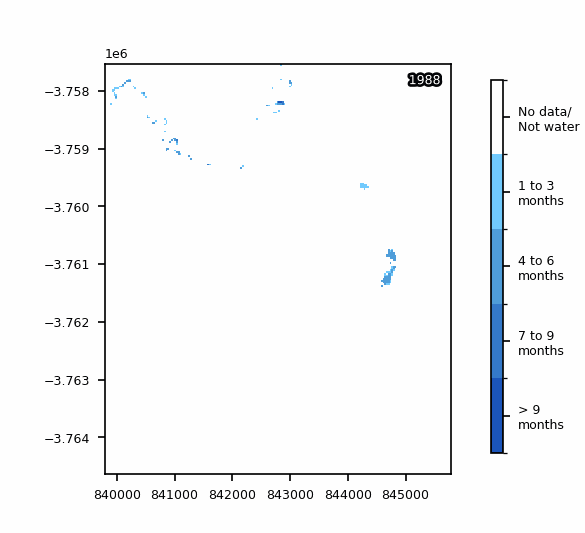

In [9]:
filename = "water_persistence_animation"

# Generate plot
lc_animation(land_cover_data['level4'], 
             file_name=filename, 
             measurement='water_persistence', 
             width_pixels=3, 
             font_size=6,
             colour_bar=True)

A stacked line plot can also be generated for the specific environmental descriptors, by using the `measurement` setting.

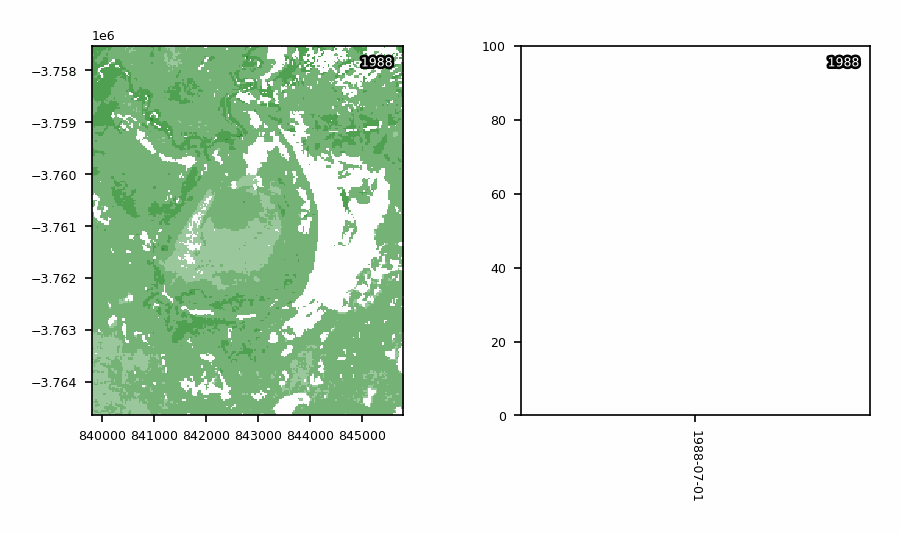

In [15]:
# descriptor name
descriptor = 'vegetation_cover'

# Set file name
file_name = f"{descriptor}with_stacked_plot"

# Generate plot
lc_animation(level_4, 
             file_name=file_name, 
             measurement=descriptor,
             width_pixels=3, 
             font_size=6,
             stacked_plot=True)

### Plot with no axes ticks

If you want to make an animation for communication purposes, perhaps you don't want to have any tick marks on the axes. In this case you include `label_ax=False`.

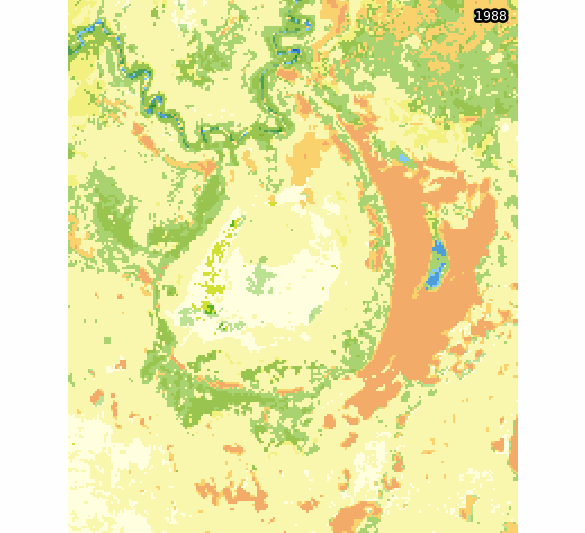

In [10]:
# Select Level 4
level_4 = land_cover_data["level4"]

# Set file name
file_name = "level_4_no_ticks_example"

# Generate plot
lc_animation(level_4, 
             file_name=file_name, 
             width_pixels=3, 
             font_size=6,
             label_ax=False)

## Why is my animation producing an error or plotting no data? 

`lc_animation()` uses the name of the `xarray.DataArray` to identify what colour map should be used to create the animation. 
If, in your analysis, you have created a new `xarray.DataArray` object you will need to ensure that you either:
1. Name the `xarray.DataArray` after the layer being plotted.
2. Use the `measurement` setting for `lc_animation()` to specify the layer. 

Plotting a layer with the incorrect colour map will result in an error or the data being plotted as nodata. 

In the next cell we do some analysis on the Level 3 classification to isolate one class. When looking at this new `xarray.DataArray`, we can see that the name is now different (`"Bare_only"` compared to `"level3"`).

In [11]:
# Select Level 3
level_3 = land_cover_data["level3"]

# Do some data manipulation then create a new Xarray.DataArray
# with a new layer name "Bare_only"
data = np.where(level_3 == 216, level_3, 255)
xr_bare = xr.DataArray(
    data=data,
    coords=level_3.coords,
    dims=level_3.dims,
    name="Bare_only",
    attrs=None,
)

xr_bare

<xarray.DataArray 'Bare_only' (time: 34, y: 237, x: 200)> Size: 2MB
array([[[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255, 255, 255, ..., 216, 216, 216],
        [255, 255, 255, ..., 216, 216, 216],
        [255, 255, 255, ..., 216, 216, 216]],

       [[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255, 255, 255, ..., 216, 216, 216],
        [255, 255, 255, ..., 216, 216, 216],
        [255, 255, 255, ..., 216, 216, 216]],

       [[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
...
        ...,
        [255, 255, 255, ..., 216, 216, 216],
        [255, 255, 255, ..., 216, 216, 216],
        [255, 255, 255, ..., 216, 216, 216]],

       [[255, 216, 255, ..., 216, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 216, ..., 216, 255, 216],
        ...,
        [255, 255, 255, ..., 255, 216, 216],
        [255, 255, 255, ..., 216, 216, 216],
        [255, 255, 255, ..., 216, 216, 216]],

       [[255, 255, 255, ..., 216, 216, 216],
        [255, 255, 255, ..., 216, 216, 255],
        [255, 255, 255, ..., 216, 216, 216],
        ...,
        [255, 255, 255, ..., 255, 216, 216],
        [255, 255, 255, ..., 255, 216, 216],
        [255, 255, 255, ..., 216, 216, 255]]], dtype=uint8)
Coordinates:
  * time         (time) datetime64[ns] 272B 1988-07-01T23:59:59.999999 ... 20...
  * y            (y) float64 2kB -3.758e+06 -3.758e+06 ... -3.765e+06 -3.765e+06
  * x            (x) float64 2kB 8.398e+05 8.398e+05 ... 8.457e+05 8.458e+05
    spatial_ref  int32 4B 3577

If we try to generate an animation for this without specifying which DEA Land Cover classification should be used to colour the plot, we will get an error. In order to avoid getting this error, we provide the name of the classification being used to the 'measurement' variable. In this case, the measurement being used is `"level3"`. 

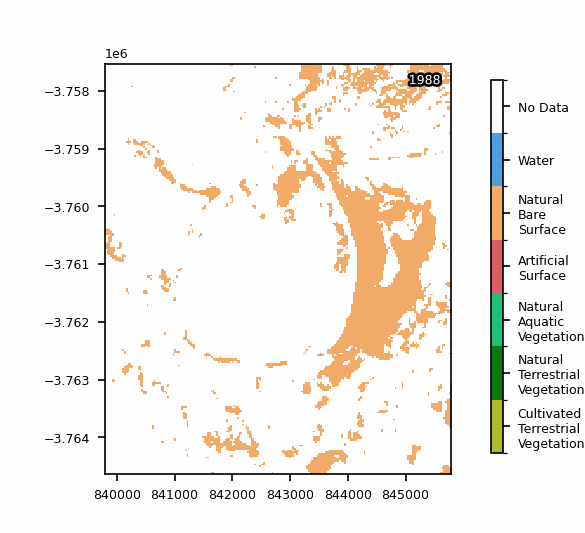

In [12]:
# Set file name
file_name = "bare_surface_example"

# Generate plot
lc_animation(xr_bare, 
             measurement='level3', 
             file_name=file_name, 
             width_pixels=3, 
             font_size=6,
             colour_bar=True, )

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** March 2025

**Compatible datacube version:** 

In [13]:
print(datacube.__version__)

1.8.19


## Tags
<!-- Browse all available tags on the DEA User Guide's [Tags Index](https://knowledge.dea.ga.gov.au/genindex/) -->